# Описание задания:
Кризис пройден. Стажировка продолжается. Теперь Вас определили в отдел аналитики маркетплейса, где необходимо поработать с данными e-commerce. Вам предстоит изучить активность магазина в различных регионах, чтобы выстроить стратегию развития.

1. Используйте датасет data_hw_2_(upd).xlsxКак работать с файлом
2. Постройте гистограммы плотности распределения объёмов продаж для Франции и Германии и определите типы распределений.
3. С помощью стат. критериев сравните объёмы продаж во Франции и Германии:
Гипотеза: «Объёмы продаж Франции отличаются от объёмов продаж Германии».
4. Сделайте выводы по результатам проверки.

Примечание: базовые гипотезы всегда формулируются одинаково, нулевая гипотеза гласит, что выборки значимо не отличаются, альтернативная – наоборот; проверяемая гипотеза всегда является альтернативной.

Чек-лист самопроверки:
- Построены графики объёмов продаж по отдельным странам.
- Проведено сравнение объёмов продаж Франции и Германии.
- Сделаны выводы по результатам проверки.

## Описание датасета:

Датасет содержит информацию о транзакциях заказов маркетплейса, e-commerce:
- InvoiceNo — номер заказа;
- CustomerID — идентификатор пользователя;
- Country — страна;
- InvoiceDate — дата заказа;
- Description — описание наименования позиции заказа;
- TotalPrice — продажи (с учётом количества единиц продукции).

In [36]:
import pandas as pd
import statistics as st
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

alpha = 0.05    # Уровень значимости

In [37]:
df = pd.read_excel('data_hw_2__upd_.xlsx')
df.head(5)

,InvoiceNo,CustomerID,Country,InvoiceDate,Description,TotalPrice
0,537693,12441,France,2010-12-08,WRAP I LOVE LONDON,51.11
1,537693,12441,France,2010-12-08,VINTAGE CARAVAN GIFT WRAP,43.61
2,537693,12441,France,2010-12-08,BLUE SCANDINAVIAN PAISLEY WRAP,73.08
3,537693,12441,France,2010-12-08,PAPER CHAIN KIT VINTAGE CHRISTMAS,39.17
4,537693,12441,France,2010-12-08,PAPER CHAIN KIT 50'S CHRISTMAS,57.48


In [38]:
display(df.describe())
display(df['Country'].unique())

,CustomerID,InvoiceDate,TotalPrice
count,1200.000000,1200,1200.000000
mean,12459.749167,2011-06-08 08:03:36,50.640212
min,12350.000000,2010-12-01 00:00:00,0.320000
25%,12433.000000,2011-01-07 00:00:00,36.312500
50%,12479.500000,2011-08-12 00:00:00,49.300000
75%,12491.000000,2011-11-01 00:00:00,63.225000
max,12535.000000,2011-12-09 00:00:00,152.700000
std,43.393783,NaN,19.966028


<StringArray>
['France', 'Germany', 'Norway']
Length: 3, dtype: str

In [39]:
df_fr = df[df['Country'] == 'France'].copy()
df_ge = df[df['Country'] == 'Germany'].copy()
print('Выборкки имеют одинаковую длинну: ', len(df_fr) == len(df_ge))

Выборкки имеют одинаковую длинну:  True


In [40]:
# Описательные статистики Франции
df_fr.describe()

,CustomerID,InvoiceDate,TotalPrice
count,400.00000,400,400.000000
mean,12478.22500,2011-08-09 03:50:24,44.190838
min,12413.00000,2010-12-08 00:00:00,4.975000
25%,12437.00000,2011-05-09 00:00:00,32.537500
50%,12490.00000,2011-10-06 00:00:00,43.430000
75%,12508.00000,2011-11-04 12:00:00,55.790000
max,12535.00000,2011-12-08 00:00:00,104.500000
std,35.97708,NaN,15.564637


In [41]:
# Описательные статистики Франции
df_ge.describe()

,CustomerID,InvoiceDate,TotalPrice
count,400.000000,400,400.000000
mean,12488.125000,2011-04-20 11:49:12,53.964900
min,12477.000000,2010-12-09 00:00:00,3.607000
25%,12480.000000,2011-01-07 00:00:00,41.422500
50%,12481.000000,2011-01-07 00:00:00,54.490000
75%,12501.000000,2011-10-05 00:00:00,67.082500
max,12501.000000,2011-12-06 00:00:00,107.600000
std,10.422617,NaN,18.674082


C:\Users\wolftik\AppData\Local\Temp\ipykernel_13596\412680662.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_fr['TotalPrice'], 50)
C:\Users\wolftik\AppData\Local\Temp\ipykernel_13596\412680662.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_ge['TotalPrice'], 50)


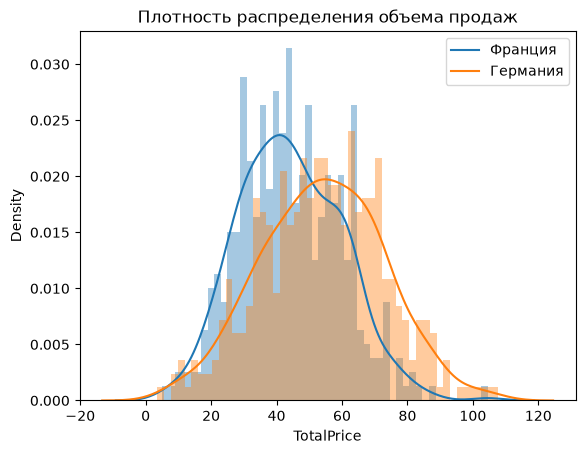

In [42]:
sns.distplot(df_fr['TotalPrice'], 50)
sns.distplot(df_ge['TotalPrice'], 50)
plt.title('Плотность распределения объема продаж')
plt.legend(['Франция', 'Германия'])
plt.show()

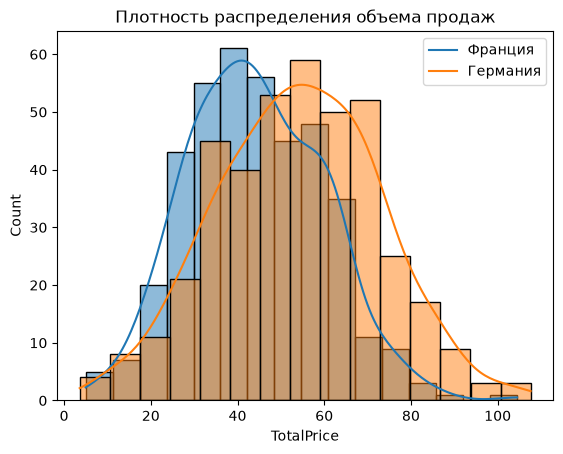

In [43]:
sns.histplot(df_fr['TotalPrice'], kde=True)
sns.histplot(df_ge['TotalPrice'], kde=True)
plt.title('Плотность распределения объема продаж')
plt.legend(['Франция', 'Германия'])
plt.show()

Проведение Т-Теста (t-критерий Стьюдента)

In [44]:

result = ttest_ind(df_fr['TotalPrice'], df_ge['TotalPrice'])
print('p-value: %.8f' % result.pvalue)

if (result.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.00000000
Отвергаем нулевую гипотезу


Проведение теста Манна — Уитни (U-критерий Манна — Уитни)

In [45]:
result = mannwhitneyu(df_fr['TotalPrice'], df_ge['TotalPrice'])
print('p-value: %.8f' % result.pvalue)

if (result.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.00000000
Отвергаем нулевую гипотезу


# Вывод

Визуальный анализ: Графики плотности распределения показывают, что в обеих странах структура продаж имеет схожую форму. Это говорит о том, что паттерны поведения покупателей в регионах примерно одинаковы. Но при детальном рассмотрении видно, что объёмы продаж в Германии преобладают над объемами продаж во Франции.

Статистическое подтверждение: Использование двух методов проверки — t-теста и критерия Манна-Уитни — позволило подтвердить наши наблюдения. Оба теста показали крайне низкое значение p-value: 0.00000000, что значительно меньше уровня значимости alpha = 0.05

Итог: отвергаем нулевую гипотезу и принимаем альтернативную, объёмы продаж в Франции и Германии статистически значимо различаются.
